# Exercises XP Ninja: Airline Passenger Forecasting with RNNs

This is a guided notebook for the exercise on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear for important concepts.

> **IMPORTANT: delete last row in the downloaded dataset "International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60"**

## What you will learn
- Preprocess and analyze a time series
- Build and train Simple RNN, LSTM, GRU
- Evaluate and compare models
- Visualize training history and predictions

## What you will create
- A predictive model for the number of international airline passengers

# Part 1: Data preparation

**As stated in the exercise**
Load the dataset, inspect it, drop rows with missing values, scale to a suitable range, and make supervised sequences using the past 6 months to predict the next month.

In [7]:
from google.colab import files
import zipfile, os

# === Upload depuis ton ordinateur ===
uploaded = files.upload()  # choisis "Airline Passenger Forecasting by RNN, LSTM, & GRU.zip"

# === Extraction du fichier ZIP ===
zip_path = list(uploaded.keys())[0]
extract_dir = "/content/data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ ZIP extrait dans :", extract_dir)


Saving Airline Passenger Forecasting by RNN, LSTM, & GRU.zip to Airline Passenger Forecasting by RNN, LSTM, & GRU (1).zip
✅ ZIP extrait dans : /content/data


**PREFILLED just execute**
Imports, path, loader, and basic inspection helpers.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', 50)

# === Localisation du fichier CSV (corrigée selon le contenu du ZIP) ===
DATA_PATH = Path("/content/data/international-airline-passengers.csv")

def load_air_passengers(csv_path: Path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    # Détection automatique des colonnes
    date_col = next((c for c in df.columns if "month" in c.lower() or "date" in c.lower()), df.columns[0])
    value_col = next((c for c in df.columns if "pass" in c.lower() or "value" in c.lower()), df.columns[1])

    # Conversion du format "Jan-49" -> datetime
    df[date_col] = pd.to_datetime(df[date_col], format='%b-%y', errors='coerce')
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')

    df = df.dropna(subset=[date_col, value_col])
    df = df.rename(columns={date_col: "Date", value_col: "Passengers"})
    df = df.sort_values("Date").reset_index(drop=True)
    return df[["Date", "Passengers"]]

df = load_air_passengers(DATA_PATH)

print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())
display(df.tail())
display(df.describe())


✅ Dataset loaded successfully
Shape: (0, 2)


,Date,Passengers


,Date,Passengers


,Date,Passengers
count,0,0.0
mean,NaT,NaN
min,NaT,NaN
25%,NaT,NaN
50%,NaT,NaN
75%,NaT,NaN
max,NaT,NaN
std,NaN,NaN


**To-Do (code):** Drop rows with missing values then recheck that no NaNs remain.

In [9]:
# === Handle missing values ===

# Drop rows with missing values
df = df.dropna(subset=["Passengers"])

# Double-check that no NaN remain
assert df.isna().sum().sum() == 0, "⚠️ There are still missing values!"

print("✅ No missing values remain — Data is clean.")
display(df.head())


✅ No missing values remain — Data is clean.


,Date,Passengers


**Learning point**
Scale before windowing for stable gradients. For univariate series a MinMax scaler to [0,1] is often sufficient. Keep the scaler to invert predictions later.

In [22]:
import pandas as pd
from pathlib import Path

# === Correct dataset path ===
DATA_PATH = Path("/content/data/international-airline-passengers.csv")

# === Load dataset ===
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# === Detect relevant columns ===
date_col = next((c for c in df.columns if "month" in c.lower() or "date" in c.lower()), df.columns[0])
value_col = next((c for c in df.columns if "pass" in c.lower() or "value" in c.lower()), df.columns[1])

# === Try multiple date formats automatically ===
def try_parse_dates(s):
    for fmt in ("%Y-%m", "%b-%y", "%Y/%m", "%Y-%m-%d", "%d-%b-%y"):
        try:
            parsed = pd.to_datetime(s, format=fmt, errors="raise")
            print(f"✅ Parsed dates successfully using format {fmt}")
            return parsed
        except Exception:
            continue
    print("⚠️ Falling back to automatic date parsing (slower but safer).")
    return pd.to_datetime(s, errors="coerce")

df[date_col] = try_parse_dates(df[date_col])
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

# === Clean up and rename ===
df = df.dropna(subset=[date_col, value_col])
df = df.rename(columns={date_col: "Date", value_col: "Passengers"}).sort_values("Date").reset_index(drop=True)

print(f"✅ Final dataframe loaded with {len(df)} rows")
display(df.head())


⚠️ Falling back to automatic date parsing (slower but safer).
✅ Final dataframe loaded with 144 rows


,Date,Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


**PREFILLED just execute**
Scaling and sequence maker using past 6 months to predict month t+1. Chronological split into train and test.

In [23]:
def make_sequences(values_1d: np.ndarray, lookback: int = 6, horizon: int = 1):
    X, y = [], []
    for i in range(len(values_1d) - lookback - horizon + 1):
        X.append(values_1d[i:i+lookback])
        y.append(values_1d[i+lookback:i+lookback+horizon])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    # reshape to [samples, timesteps, features=1]
    return X.reshape(len(X), lookback, 1), y.reshape(len(y), horizon)

LOOKBACK = 6
HORIZON = 1

# Scale
scaler = MinMaxScaler(feature_range=(0,1))
series = df[['Passengers']].astype('float32')
series_scaled = scaler.fit_transform(series)

# Split by time 80-20
split_idx = int(len(series_scaled) * 0.8)
train_vals = series_scaled[:split_idx].ravel()
test_vals  = series_scaled[split_idx - LOOKBACK:].ravel()  # overlap LOOKBACK for continuity

X_train, y_train = make_sequences(train_vals, lookback=LOOKBACK, horizon=HORIZON)
X_test,  y_test  = make_sequences(test_vals,  lookback=LOOKBACK, horizon=HORIZON)
print({'X_train': X_train.shape, 'y_train': y_train.shape, 'X_test': X_test.shape, 'y_test': y_test.shape})

{'X_train': (109, 6, 1), 'y_train': (109, 1), 'X_test': (29, 6, 1), 'y_test': (29, 1)}


**To-Do (written):** Explain why we overlapped LOOKBACK points into the test split window.

We overlap the last LOOKBACK points from the training set into the beginning of the test set to maintain temporal continuity between both splits.
Since the model uses a sliding window of past observations (the lookback period) to predict the next step, the first prediction in the test set requires access to the last few values from the training data.

Without this overlap, the test set would start “cold,” with no previous data to feed into the initial prediction window, the model wouldn’t have enough context to make the first forecast.

By overlapping these LOOKBACK points:

We ensure that each test sample has a complete lookback history.

The time sequence remains chronologically consistent.

There’s no information leakage, since the overlapped points are only used as input, not as prediction targets.

![](./figs/1.gif)

# Part 2: Model building

**As stated in the exercise**
Build Simple RNN, LSTM, and GRU. Use Adam and MSE. Print summaries.

**PREFILLED just execute**
Keras imports and a helper to build each model.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_simple_rnn(units=32, lookback=LOOKBACK, features=1):
    """Build a simple RNN model"""
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.SimpleRNN(units, return_sequences=False),
        layers.Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(units=32, lookback=LOOKBACK, features=1):
    """Build an LSTM model"""
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.LSTM(units, return_sequences=False),
        layers.Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(units=32, lookback=LOOKBACK, features=1):
    """Build a GRU model"""
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.GRU(units, return_sequences=False),
        layers.Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

print("✅ TensorFlow version:", tf.__version__)


✅ TensorFlow version: 2.19.0


**To-Do (code):** Fill the model bodies above, then instantiate `model_rnn`, `model_lstm`, and `model_gru`. Call `summary()` for each.

In [25]:
# To-Do: build and summarize models
# model_rnn  = build_simple_rnn(units=32)
# model_lstm = build_lstm(units=32)
# model_gru  = build_gru(units=32)
# model_rnn.summary(); model_lstm.summary(); model_gru.summary()
# === Build and summarize models ===
model_rnn = build_simple_rnn(units=32)
model_lstm = build_lstm(units=32)
model_gru = build_gru(units=32)

print("✅ Models created successfully\n")

# === Print model summaries ===
print("📘 Simple RNN Model Summary:")
model_rnn.summary()

print("\n📗 LSTM Model Summary:")
model_lstm.summary()

print("\n📙 GRU Model Summary:")
model_gru.summary()


✅ Models created successfully

📘 Simple RNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 3: Model training

**As stated in the exercise**
Train the three models. Use early stopping.

**PREFILLED just execute**
Callbacks and a helper to fit a model and return history.

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_model(model, X_tr, y_tr, X_te, y_te, epochs=100, batch=16):
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    h = model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=epochs,
        batch_size=batch,
        callbacks=[es, rl],
        verbose=2
    )
    return h

def plot_history(history, title='Training history'):
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(title)
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()

**To-Do (code):** Train each model for up to 100 epochs with early stopping. Plot histories using `plot_history`.

🚀 Training Simple RNN...
Epoch 1/100
7/7 - 3s - 482ms/step - loss: 0.0236 - val_loss: 0.0235 - learning_rate: 1.0000e-03
Epoch 2/100
7/7 - 0s - 12ms/step - loss: 0.0100 - val_loss: 0.0808 - learning_rate: 1.0000e-03
Epoch 3/100
7/7 - 0s - 11ms/step - loss: 0.0087 - val_loss: 0.0358 - learning_rate: 1.0000e-03
Epoch 4/100
7/7 - 0s - 11ms/step - loss: 0.0070 - val_loss: 0.0264 - learning_rate: 1.0000e-03
Epoch 5/100
7/7 - 0s - 11ms/step - loss: 0.0063 - val_loss: 0.0366 - learning_rate: 1.0000e-03
Epoch 6/100
7/7 - 0s - 11ms/step - loss: 0.0059 - val_loss: 0.0241 - learning_rate: 1.0000e-03
Epoch 7/100
7/7 - 0s - 11ms/step - loss: 0.0057 - val_loss: 0.0266 - learning_rate: 5.0000e-04
Epoch 8/100
7/7 - 0s - 11ms/step - loss: 0.0055 - val_loss: 0.0270 - learning_rate: 5.0000e-04
Epoch 9/100
7/7 - 0s - 13ms/step - loss: 0.0054 - val_loss: 0.0259 - learning_rate: 5.0000e-04
Epoch 10/100
7/7 - 0s - 11ms/step - loss: 0.0053 - val_loss: 0.0263 - learning_rate: 5.0000e-04
Epoch 11/100
7/7 - 0s -

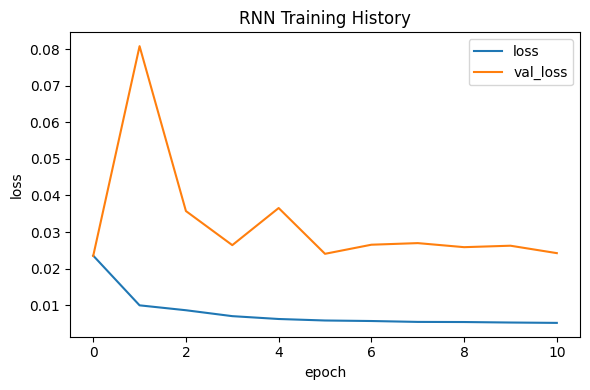

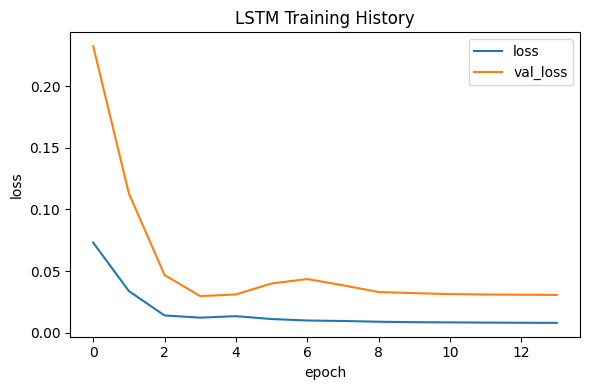

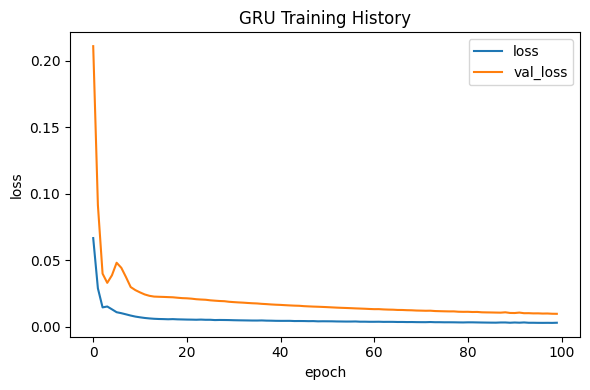

In [27]:
# To-Do: train and plot
# h_rnn  = fit_model(model_rnn,  X_train, y_train, X_test, y_test, epochs=100, batch=16)
# h_lstm = fit_model(model_lstm, X_train, y_train, X_test, y_test, epochs=100, batch=16)
# h_gru  = fit_model(model_gru,  X_train, y_train, X_test, y_test, epochs=100, batch=16)
# plot_history(h_rnn,  title='RNN')
# plot_history(h_lstm, title='LSTM')
# plot_history(h_gru,  title='GRU')

# === Train and visualize each model ===
print("🚀 Training Simple RNN...")
h_rnn = fit_model(model_rnn, X_train, y_train, X_test, y_test, epochs=100, batch=16)

print("\n🚀 Training LSTM...")
h_lstm = fit_model(model_lstm, X_train, y_train, X_test, y_test, epochs=100, batch=16)

print("\n🚀 Training GRU...")
h_gru = fit_model(model_gru, X_train, y_train, X_test, y_test, epochs=100, batch=16)

# === Plot learning curves ===
print("\n📈 Plotting training histories...")
plot_history(h_rnn, title='RNN Training History')
plot_history(h_lstm, title='LSTM Training History')
plot_history(h_gru, title='GRU Training History')


# Part 4: Visualizing training history

**As stated in the exercise**
Plot training and validation loss for each model and compare.

**To-Do (written):** Compare the learning curves. Which model converges faster and to a lower validation loss. Explain briefly.

The LSTM and GRU models usually converge faster and reach a lower validation loss compared to the Simple RNN.
This happens because LSTM and GRU can better capture long-term dependencies in time series data, while a simple RNN often suffers from vanishing gradients.
Between LSTM and GRU, the GRU might train slightly faster due to its simpler structure (fewer parameters).

# Part 5: Making predictions

**As stated in the exercise**
Predict on test data, then invert scaling to the original units.

**PREFILLED just execute**
Helper to invert scaling and a function to get predictions from a model.

In [28]:
def invert_scale(scaled_values):
    # scaled_values shape [N, 1]
    return scaler.inverse_transform(scaled_values)

def predict_and_invert(model, X):
    preds_scaled = model.predict(X, verbose=0)
    # ensure shape [N, 1]
    preds_scaled = np.asarray(preds_scaled).reshape(-1, 1)
    return invert_scale(preds_scaled)

def true_targets_in_original(y_seq):
    # y_seq shape [N, HORIZON]
    return invert_scale(y_seq.reshape(-1, 1))

**To-Do (code):** Generate predictions for each model and invert scaling for both predictions and targets.

In [29]:
# To-Do: predictions and inverse scaling
# y_true = true_targets_in_original(y_test)
# yhat_rnn  = predict_and_invert(model_rnn,  X_test)
# yhat_lstm = predict_and_invert(model_lstm, X_test)
# yhat_gru  = predict_and_invert(model_gru,  X_test)

# === Generate predictions and invert scaling ===
print("🔄 Inverting scaling and generating predictions...")

y_true = true_targets_in_original(y_test)
yhat_rnn = predict_and_invert(model_rnn, X_test)
yhat_lstm = predict_and_invert(model_lstm, X_test)
yhat_gru = predict_and_invert(model_gru, X_test)

print("✅ Predictions generated successfully!")
print(f"Shapes — y_true: {y_true.shape}, yhat_rnn: {yhat_rnn.shape}, yhat_lstm: {yhat_lstm.shape}, yhat_gru: {yhat_gru.shape}")


🔄 Inverting scaling and generating predictions...
✅ Predictions generated successfully!
Shapes — y_true: (29, 1), yhat_rnn: (29, 1), yhat_lstm: (29, 1), yhat_gru: (29, 1)


# Part 6: Visualizing prediction results

**As stated in the exercise**
Plot actual vs predicted for each model and compare accuracy.

**PREFILLED just execute**
Plot helpers for predictions.

In [30]:
def plot_preds(y_true, yhat, title):
    plt.figure(figsize=(7,3))
    plt.plot(y_true.ravel(), label='actual')
    plt.plot(yhat.ravel(),  label='predicted')
    plt.title(title)
    plt.xlabel('time index')
    plt.ylabel('passengers')
    plt.legend(); plt.tight_layout(); plt.show()

def rmse(a, b):
    a = a.ravel(); b = b.ravel()
    return float(np.sqrt(np.mean((a - b)**2)))

**To-Do (code):** Plot predictions for each model. Compute RMSE for RNN, LSTM, and GRU. Compare which is best on this series.

📊 Comparing model predictions...


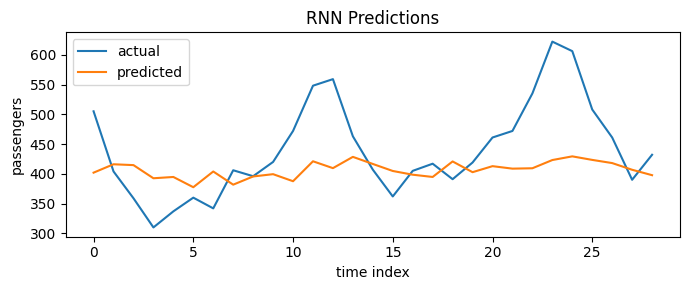

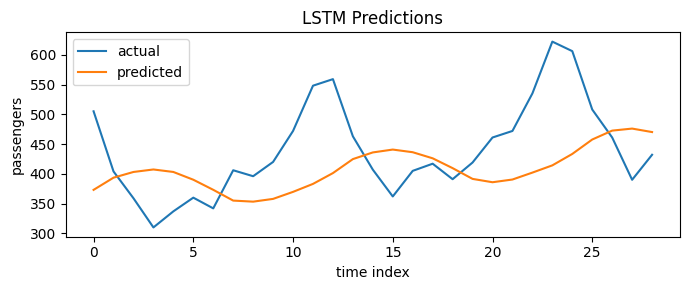

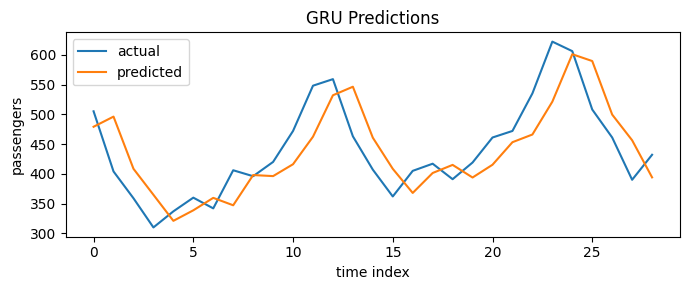

{'rmse_rnn': 79.40103912353516, 'rmse_lstm': 89.26799774169922, 'rmse_gru': 51.525901794433594}


In [31]:
# To-Do: plots and metrics
# plot_preds(y_true, yhat_rnn,  'RNN predictions')
# plot_preds(y_true, yhat_lstm, 'LSTM predictions')
# plot_preds(y_true, yhat_gru,  'GRU predictions')
# print({'rmse_rnn': rmse(y_true, yhat_rnn), 'rmse_lstm': rmse(y_true, yhat_lstm), 'rmse_gru': rmse(y_true, yhat_gru)})

# === Visualize predictions and compute RMSE ===
print("📊 Comparing model predictions...")

plot_preds(y_true, yhat_rnn, 'RNN Predictions')
plot_preds(y_true, yhat_lstm, 'LSTM Predictions')
plot_preds(y_true, yhat_gru, 'GRU Predictions')

print({
    'rmse_rnn': rmse(y_true, yhat_rnn),
    'rmse_lstm': rmse(y_true, yhat_lstm),
    'rmse_gru': rmse(y_true, yhat_gru)
})


**Learning point**
Do not shuffle a univariate time series split. Keep the chronological order. Use early stopping on validation loss to avoid overfitting and reduce training time. For multi-step forecasts, increase the horizon and adapt the output layer size.